In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bacco
from random import sample 
import copy
import h5py
import matplotlib

In [44]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

In [2]:
import os
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# Load the Halo Selection
with open("/cosmos_storage/simulations/TNG_Family/MN5_resims/resims_info/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))

final_sel = np.array(final_sel)

In [32]:
# Load MTNG and get the fraction of halos to do the upweighting
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/TNG_Family/MTNG/", snap=264)

m200b = np.log10(1e10 * mtng.fof['halo_m200b'])
mfof = np.log10(1e10 * mtng.fof['halo_mfof'])

mbins = np.concatenate(
    (np.arange(11, 11.5, 0.0025),
    np.arange(11.5, 12.5, 0.005),
    np.arange(12.5, 13.5, 0.025),
    np.arange(13.5, 15.01, 0.125))
)

h_frac = np.zeros(len(final_sel))
for m in range(len(mbins)-1):
    h_frac[m] = np.where(( m200b[final_sel]>=mbins[m]) & ( m200b[final_sel]<mbins[m+1]))[0].shape[0] / \
             np.where(( m200b>=mbins[m]) & ( m200b<mbins[m+1]))[0].shape[0]

2026-03-05 17:46:25,613 bacco.sims : Initialising simulation Default
2026-03-05 17:46:25,614 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-03-05 17:46:25,620 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-03-05 17:46:25,647 bacco.sims : ...done in 0.0107 s
2026-03-05 17:46:25,652 bacco.sims : Reading 98233510 items for Group_M_Mean200


/tmp/ipykernel_317119/2930380673.py:4: RuntimeWarning: divide by zero encountered in log10
  m200b = np.log10(1e10 * mtng.fof['halo_m200b'])
2026-03-05 17:46:27,654 bacco.sims : Reading 98233510 items for GroupLen


In [14]:
## Load the Zooms
sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 264
base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/"
zoom = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, dm_file="snapdir_{:03d}/snapshot_{:03d}".format(snap,snap), use_ids=True, numpart=4320)

2026-03-05 17:32:45,443 bacco.sims : Initialising simulation Default
2026-03-05 17:32:45,444 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2026-03-05 17:32:45,446 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264


2026-03-05 17:32:45,824 bacco.sims : ...done in 0.0069 s


In [73]:
mask = zoom.fof['halo_mfof_type'][:,1] > 0
frac_bad = (zoom.fof['halo_mfof_type'][:,2] + zoom.fof['halo_mfof_type'][:,3]) / zoom.fof['halo_mfof_type'][:,1]
nobad = (frac_bad < 0.008) & mask

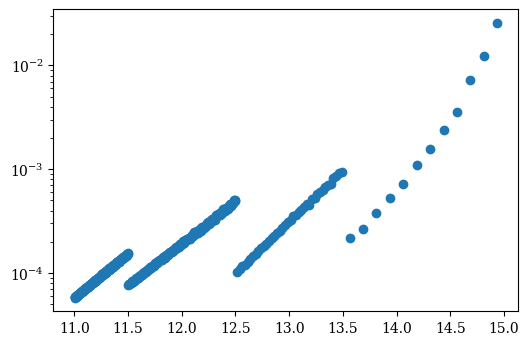

In [114]:
fig, ax = plt.subplots(dpi=100)

ax.set_yscale("log")
ax.plot(0.5*(mbins[1:]+mbins[:-1]), h_frac, marker="o", linestyle="")

In [115]:
zoom.fof.keys()

dict_keys(['nhalos_in_file', 'nhalos', 'halo_offsets', 'halo_pos', 'halo_cm', 'halo_vel', 'halo_mfof', 'halo_len', 'halo_lenType', 'halo_nsubs', 'halo_mvir', 'halo_m200c', 'halo_m200b', 'halo_m500c', 'halo_r200c', 'halo_r200b', 'halo_r500c', 'halo_vdisp_vir', 'halo_vdisp_200c', 'halo_vdisp_200b', 'halo_radial_bins', 'halo_radial_shells', 'halo_radial_bins_end', 'halo_volume_bins', 'halo_density_profile', 'halo_mbid', 'halo_dilution_factor', 'halo_firstsub', 'halo_moment_of_inertia', 'halo_mfof_type', 'halo_sdm', 'halo_logrho0', 'halo_rs', 'halo_conc'])

/tmp/ipykernel_317119/3035538100.py:11: RuntimeWarning: divide by zero encountered in log10
  ax.hist(np.log10(zoom.fof['halo_m200b'][nobad])+10, bins=np.linspace(9.5,15.5,28), density=False, label="Zoom Uncontamined", histtype="step", lw=3, color="C2");


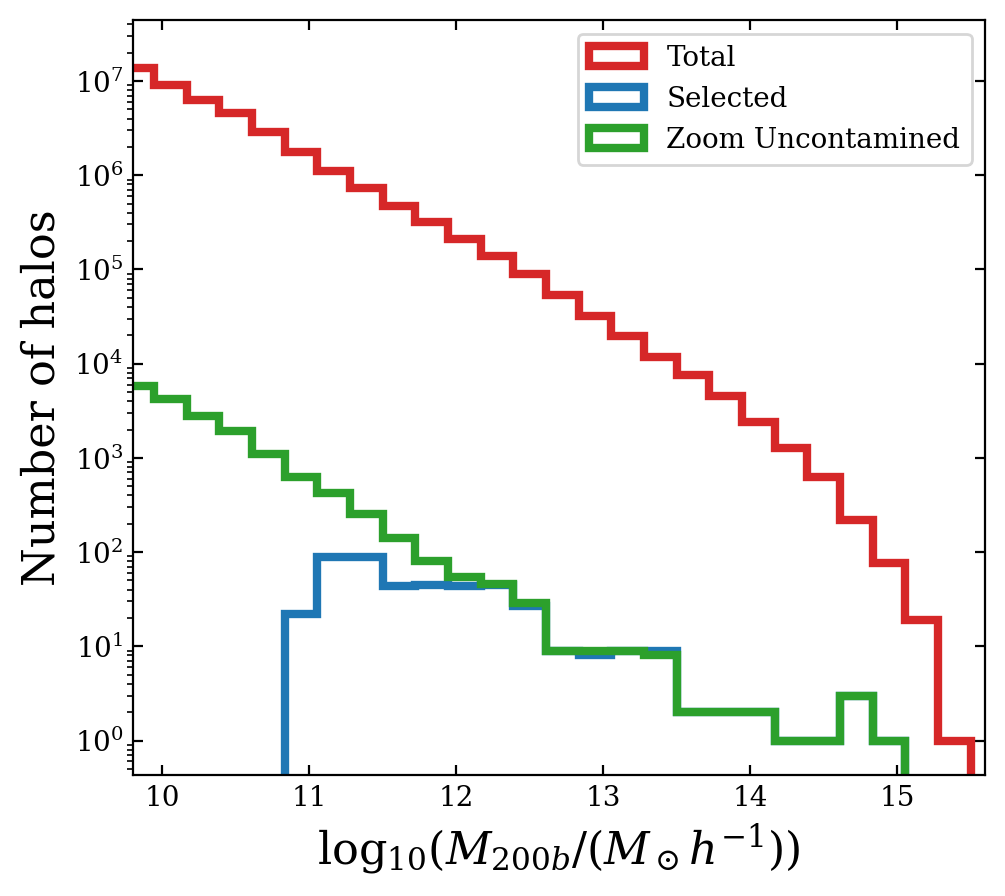

In [78]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.tick_params(direction='in', top=True, right=True)
ax.set_ylabel("Number of halos", fontsize=16)
ax.set_xlabel(r"$\log_{10}(M_{200b}/(M_\odot h^{-1}))$", fontsize=16)
ax.set_xlim(9.8,15.6)

ax.set_yscale("log")
ax.hist(m200b, bins=np.linspace(9.5,15.5,28), density=False, label="Total", histtype="step", lw=3, color='C3');
ax.hist(m200b[final_sel], bins=np.linspace(9.5,15.5,28), density=False, label="Selected", histtype="step", lw=3, color="C0");
ax.hist(np.log10(zoom.fof['halo_m200b'][nobad])+10, bins=np.linspace(9.5,15.5,28), density=False, label="Zoom Uncontamined", histtype="step", lw=3, color="C2");

ax.legend()

In [150]:
xmatch1 = utils.cross_match(zoom, snap=264, name='fiducial')
xmatch2 = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/halo_selection/vmax_cross_match_fiducial.npy", allow_pickle=True).item()

(1e-05, 1000.0)

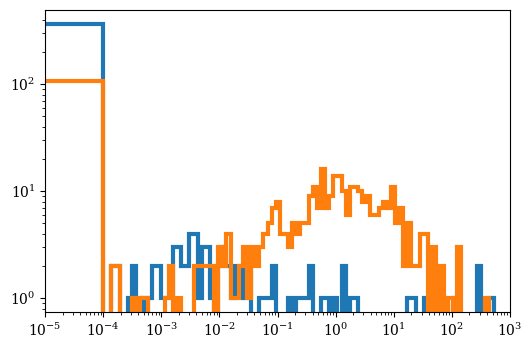

In [152]:
fig, ax = plt.subplots(dpi=100)

bins = np.concatenate((np.zeros(1),np.logspace(-4,3,100)))

ax.set_yscale("log")
ax.set_xscale("log")
hist = ax.hist(frac_bad[xmatch1['ind']], bins=bins, lw=3, histtype='step')
hist2 = ax.hist(frac_bad[xmatch2['ind']], bins=bins, lw=3, histtype='step')

ax.set_xlim(1e-5, 1e3)

In [6]:
def save_halo_sel(sel_mask, vmax_sel=False, Nhalos=None):

    idx = []
    if vmax_sel is True:
        for m in range(len(sel_mask['vmax_Custom']['h_idx'])):
            for v in range(len(sel_mask['vmax_Custom']['h_idx'][m])):
                idx.extend(sel_mask['vmax_Custom']['h_idx'][m][v])

        idx = np.unique(np.array(idx))

        with open("/lscratch/fgmaion/MTNG-resims/halo_selections/1080-A/{:d}/vmax_custom_sel.txt".format(Nhalos), 'w') as f:
            for i in range(len(idx)):
                if i==len(idx)-1:
                    f.write(str(idx[i]))
                else:
                    f.write(str(idx[i])+'\n')

    else:
        idx = sel_mask['Custom']['h_idx']

        np.save("/lscratch/fgmaion/MTNG-resims/halo_selections/1080-A/{:d}/regular_selection".format(Nhalos), [idx])

    return 1


In [51]:
basedir = "/cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/"

resolution_level = 1

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME
numpart = int(1080**3)

mtng_dm = bacco.Simulation(basedir=basedir, dm_file="snapdir_264/snapshot_264", halo_file="groups_264/fof_subhalo_tab_264", sim_format='gadget4_hdf5', fixedPk=True, sigma8=sigma8,\
    tau=tau, ns=ns, numpart=numpart, use_orphans=False, use_ids=False)

2024-08-05 10:32:10,989 bacco.sims : Initialising simulation Default
2024-08-05 10:32:10,990 bacco.sims : try /cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/snapdir_264/snapshot_264
2024-08-05 10:32:11,045 bacco.sims : Loading /cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-1080-A/snapdir_264/snapshot_264
2024-08-05 10:32:11,066 bacco.sims : ...done in 0.0772 s


In [55]:
mtng_dm.fof['halo_pos'][:,0] = ( mtng_dm.fof['halo_pos'][:,0] - 125 ) % 500

In [52]:
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/MTNG/", snap=264)
mtng.fof['halo_pos'][:,0] = ( mtng.fof['halo_pos'][:,0] - 125 ) % 500

2024-08-05 10:32:16,933 bacco.sims : Initialising simulation Default
2024-08-05 10:32:16,934 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-08-05 10:32:16,937 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-08-05 10:32:16,940 bacco.sims : ...done in 0.00699 s
2024-08-05 10:32:16,945 bacco.sims : Reading 98233510 items for GroupPos


## Check that the 125 shift worked

In [56]:
grid_mtng = bacco.statistics.compute_mesh(pos=mtng.fof['halo_pos'], box=500)
grid_dm_1080 = bacco.statistics.compute_mesh(pos=mtng_dm.fof['halo_pos'], box=500)

Text(0.5, 1.0, 'DM-only')

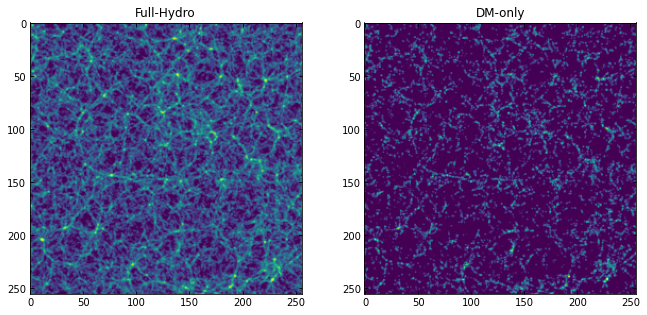

In [57]:
fig, ax = plt.subplots(1,2, figsize=(11,5))

ax[0].imshow(np.log10(1+grid_mtng[0,:,:,0]))
ax[1].imshow(np.log10(1+grid_dm_1080[0,:,:,0]))

ax[0].set_title('Full-Hydro')
ax[1].set_title('DM-only')

### Select the halos

In [10]:
Nbins = 30
hydro_split = utils.split_halos(mtng)
hydro_split.halo_sel_setup()

2024-08-05 10:16:33,893 bacco.sims : Reading 98233510 items for Group_M_Mean200


2024-08-05 10:16:55,897 bacco.sims : Reading 90246895 items for SubhaloVmax
2024-08-05 10:17:54,534 bacco.sims : Reading 98233510 items for halo_firstsub
2024-08-05 10:18:24,772 bacco.sims : Reading 98233510 items for Group_M_Mean200
/lscratch/fgmaion/MTNG-resims/src/utils.py:21: RuntimeWarning: invalid value encountered in divide
  self.halo_v200 = np.sqrt(G_newton*self.m200b/self.r200b)


### Define ranges of halo mass

In [11]:
mbins = np.concatenate(
    (np.arange(11, 11.5, 0.0025),
    np.arange(11.5, 12.5, 0.005),
    np.arange(12.5, 13.5, 0.025),
    np.arange(13.5, 15.01, 0.125))
)

In [12]:
mass_edges = np.array(list(zip(mbins[:-1], mbins[1:])))

### Plot their Mass and Concentration

In [13]:
m200b = 1e10 * mtng.fof['halo_m200b']
M_T = np.sum(m200b)

presel = np.where(m200b>10**mass_edges[0,0])

m200b = m200b[presel]

In [14]:
halo_vmax = mtng.sub['vmax'][mtng.fof['halo_firstsub']][presel]
r200b = mtng.fof['halo_r200b'][presel]
G_newton = 4.3009172706e-9 #Mpc/M_sun * (km/s)**2
halo_v200 = np.sqrt(G_newton*m200b/r200b)
vmax_v200 = halo_vmax / halo_v200

In [15]:
sel_total = hydro_split.halo_sel(mhalo_edges=mass_edges, Nhalos=None)

0.26914262771606445
0.26929306983947754
1.8209149837493896


In [16]:
ens_sel = hydro_split.halo_sel(mhalo_edges=mass_edges, Nhalos=1, draws=100)

0.2259387969970703
0.22609758377075195
8.325406312942505


### Visualize our selection

Compute their mass-fractions

In [17]:
mfrac = np.zeros(100)

for d in range(100):
    for m in range(mass_edges.shape[0]):
        mfrac[d] += np.sum(m200b[ens_sel['sel'][m][d]]) / M_T

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


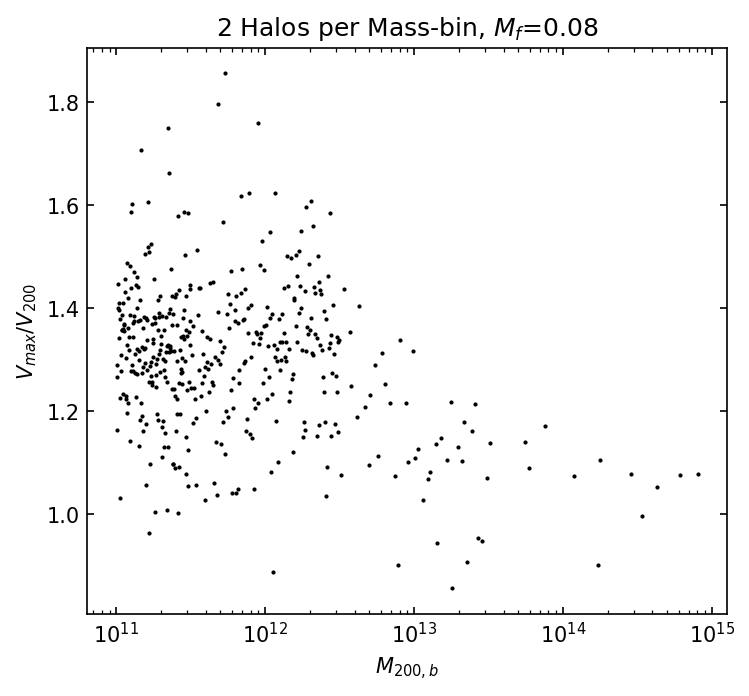

In [18]:
fig, ax = plt.subplots( dpi=150, figsize=(5.5,5), sharey=True, sharex=True)

ax.set_xscale('log')
#ax[0].set_yscale('log')

ax.set_xlabel('$M_{200,b}$')
ax.set_ylabel('$V_{max}/V_{200}$')

ax.set_title('2 Halos per Mass-bin, $M_f$={:.2f}'.format(100*np.mean(mfrac)))

for m in range(mass_edges.shape[0]):
    ax.plot(m200b[ens_sel['sel'][m][0]], vmax_v200[ens_sel['sel'][m][0]], marker='o', ls='', color='k', ms=1)

ax.legend(loc='upper left')

# ax[1,0].set_xscale('log')
# #ax[0].set_yscale('log')

# ax[1,0].set_xlabel('$M_{200,b}$')
# ax[1,0].set_ylabel('$V_{max}/V_{200}$')

# ax[1,0].set_title('2 Halos per Mass-bin, $M_f$={:.2f}'.format(100*np.mean(mfrac_vmax['2'])))

# for m in range(mass_edges.shape[0]):
#     ax[1,0].plot(m200b[ens_sel_vmax['2']['sel'][m][0]], vmax_v200[ens_sel_vmax['2']['sel'][m][0]], marker='o', ls='', color='k', ms=1)

# ax[1,0].legend(loc='upper left')

# ax[1,1].set_xscale('log')
# #ax[1].set_yscale('log')

# ax[1,1].set_xlabel('$M_{200,b}$')

# ax[1,1].set_title('4 Halos per Mass-bin, $M_f$={:.2f}'.format(100*np.mean(mfrac_vmax['4'])))

# cmap = matplotlib.cm.get_cmap('viridis')

# for m in range(mass_edges.shape[0]):
#     ax[1,1].plot(m200b[ens_sel_vmax['4']['sel'][m][0]], vmax_v200[ens_sel_vmax['4']['sel'][m][0]], marker='o', ls='', color='k', ms=1)

# ax[1,1].legend(loc='upper left')

### SMF for these selections

In [73]:
nbins=30

In [74]:
ens_smf = np.zeros((100, nbins-1))
ens_mstar = np.zeros((100, nbins-1))
weights = np.ones((100, nbins-1))

temp = hydro_split.halo_smf(sel_mask=ens_sel, nbins=nbins, mhalo_edges=mass_edges, draws=100)

for i in range(100):
    ens_smf[i] = temp['smf'][i]
    ens_mstar[i] = temp['mstar'][i]
    weights[i][np.where(np.isnan(ens_mstar[i]))] = 0
    ens_mstar[i][np.where(np.isnan(ens_mstar[i]))] = 0
    ens_smf[i][np.where(np.isnan(ens_mstar[i]))] = 0

2024-08-05 15:46:08,862 bacco.sims : Reading 98233510 items for GroupNsubs
2024-08-05 15:46:12,349 bacco.sims : Reading 90246895 items for SubhaloMassType
/lscratch/fgmaion/MTNG-resims/src/utils.py:211: RuntimeWarning: invalid value encountered in divide
  mstar_mean[d] = mstar_mean[d] / counts[d]


In [75]:
mean_smf   = np.sum(ens_smf, axis=0) / np.sum(weights, axis=0)
mean_mstar = np.sum(ens_mstar, axis=0) / np.sum(weights, axis=0)
err_smf    = np.sqrt( np.sum(ens_smf**2, axis=0) / np.sum(weights, axis=0) - ( np.sum(ens_smf, axis=0) / np.sum(weights, axis=0) )**2 )

In [76]:
smf_total = hydro_split.total_smf(nbins=nbins)

In [77]:
GAMA = np.array([
    [6.875, -0.691, 0.176],
    [7.125, -1.084, 0.125],
    [7.375, -1.011, 0.071],
    [7.625, -1.349, 0.092],
    [7.875, -1.287, 0.079],
    [8.125, -1.544, 0.071],
    [8.375, -1.669, 0.045],
    [8.625, -1.688, 0.032],
    [8.875, -1.795, 0.024],
    [9.125, -1.886, 0.020],
    [9.375, -2.055, 0.014],
    [9.625, -2.142, 0.010],
    [9.875, -2.219, 0.009],
    [10.125, -2.274, 0.009],
    [10.375, -2.292, 0.009],
    [10.625, -2.361, 0.010],
    [10.875, -2.561, 0.013],
    [11.125, -2.922, 0.019],
    [11.375, -3.414, 0.032],
    [11.625, -4.704, 0.138]
])

In [78]:
GAMA_corr = np.zeros((GAMA.shape[0], 4))
GAMA_corr[:,0] = 10**GAMA[:,0] / 0.7**2
GAMA_corr[:,1] = 10**GAMA[:,1] * 0.7**3

GAMA_corr[:,2] = 10**GAMA[:,1] - 10**(GAMA[:,1] - GAMA[:,2])
GAMA_corr[:,3] = 10**(GAMA[:,1] + GAMA[:,2]) - 10**GAMA[:,1]

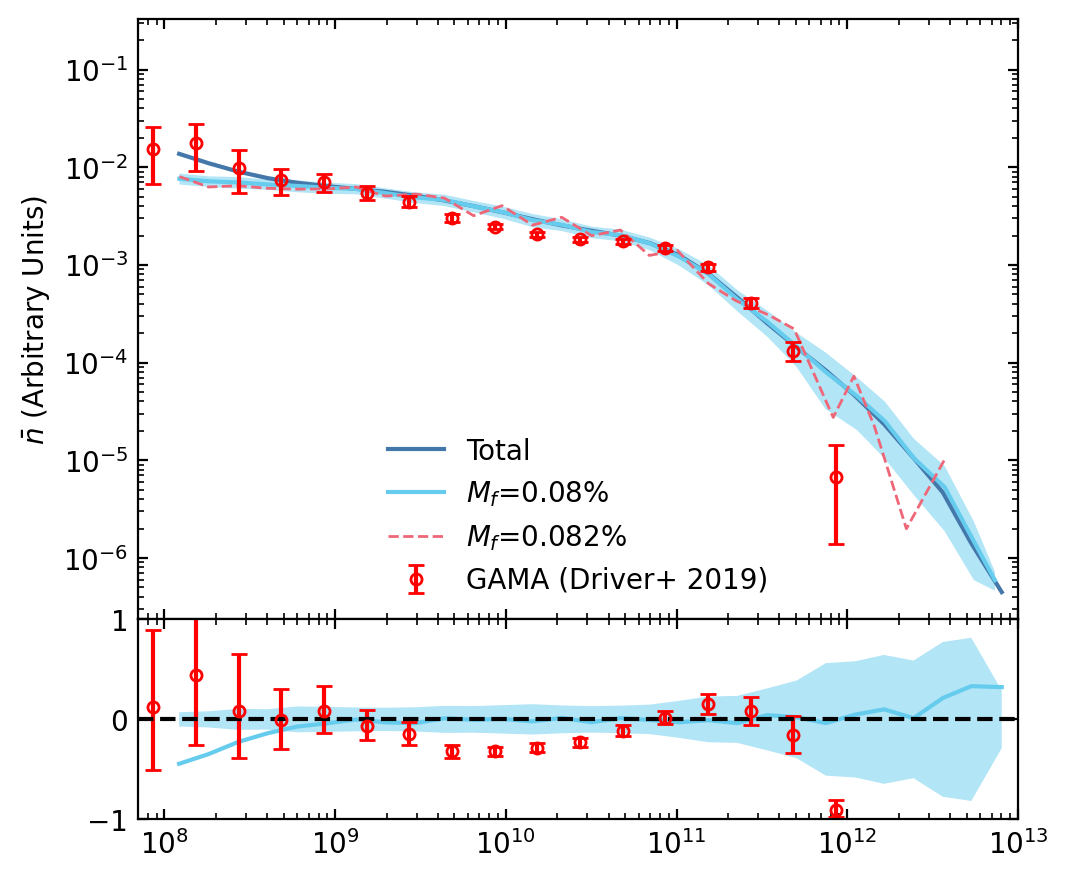

In [79]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

colors=[ '#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB']

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.set_xlim(7e7,1e13)

ax1.plot(smf_total['mstar'], smf_total['smf'], label='Total', color=colors[0])
ax1.plot(mean_mstar, mean_smf, color=colors[1], label='$M_f$={:.2f}%'.format(100*np.mean(mfrac))) 

ax1.fill_between(mean_mstar, mean_smf-err_smf, mean_smf+err_smf, color=colors[1], alpha=0.5, edgecolor=None)

# for i in range(25,30):
#   ax1.plot(ens_mstar[i], ens_smf[i])

ax1.plot(ens_mstar[28][:-2], ens_smf[28][:-2], color=colors[4], ls='--', label='$M_f$={:.3f}%'.format(100*mfrac[28]), lw=1)
# ax1.plot(ens_mstar[8], ens_smf[8], color=colors[4], ls='--', label='$M_f$={:.3f}%'.format(100*mfrac[8]), lw=1)
# ax1.plot(ens_mstar[87], ens_smf[87], color=colors[2], ls='--', label='$M_f$={:.3f}%'.format(100*mfrac[87]), lw=1)
# ax1.plot(ens_mstar[92], ens_smf[92], color=colors[4], ls='--', label='$M_f$={:.3f}%'.format(100*mfrac[92]), lw=1)

ax1.errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], color='r', marker='o', capsize=3, ms=4, fillstyle='none', ls='', label='GAMA (Driver+ 2019)')

ax1.legend(loc='lower center')

ax1.set_ylabel('$\\bar{n}$ (Arbitrary Units)')
ax1.set_xticklabels([])

ax2=fig.add_axes((.1,.1,.8,.2))        

ax2.set_xlim(7e7,1e13)

ax2.set_xscale('log')

ax2.plot(smf_total['mstar'], np.interp(smf_total['mstar'], mean_mstar, mean_smf)/smf_total['smf'] - 1, color=colors[1])

ax2.fill_between(smf_total['mstar'], -np.interp(smf_total['mstar'], mean_mstar, err_smf)/smf_total['smf'], np.interp(smf_total['mstar'], mean_mstar, err_smf)/smf_total['smf'], color=colors[1], alpha=0.5, edgecolor=None)

ax2.errorbar(GAMA_corr[:,0], GAMA_corr[:,1]/np.interp(GAMA_corr[:,0], smf_total['mstar'], smf_total['smf']) - 1, yerr=[GAMA_corr[:,2], GAMA_corr[:,3]]/np.interp(GAMA_corr[:,0], smf_total['mstar'], smf_total['smf']),\
 marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')

ax2.set_ylim(-1,1)
ax2.axhline(0, ls='--', color='k')

# ax2.set_ylim(-0.5,0.5)

# #ax2.fill_between(centers, -0.05,0.05, color='gray', alpha=0.1)
# #ax2.fill_between(centers, -0.1,0.1, color='gray', alpha=0.1)

# ax2.set_ylabel('$\log_{10}(\\bar{n}/\\bar{n}_T)$')
# ax2.set_xlabel('$M_*[M_{\odot}/h]$')




## What about gas-fraction

In [29]:
m500_bins = np.arange(10, 15, 0.1)
m500_edges = np.array(list(zip(m500_bins[:-1], m500_bins[1:])))

In [30]:
nbins=11

ens_fgas = np.zeros((100, nbins-1))
ens_m500 = np.zeros((100, nbins-1))
weights = np.ones((100, nbins-1))

temp = hydro_split.halo_gas_frac(mhalo_edges=mass_edges, sel_mask=ens_sel, vmax_sel=False, nbins=nbins, draws=100)

for i in range(100):
    ens_fgas[i] = temp['f_gas'][i]
    ens_m500[i] = temp['m500c'][i]

    weights[i][np.where(np.isnan(ens_m500[i]))] = 0

    ens_fgas[i][np.where(np.isnan(ens_m500[i]))] = 0
    ens_m500[i][np.where(np.isnan(ens_m500[i]))] = 0

2024-08-02 14:43:17,534 bacco.sims : Reading 98233510 items for Group_M_Crit500
/lscratch/fgmaion/MTNG-resims/src/utils.py:274: RuntimeWarning: invalid value encountered in divide
  fgas[d] /= weights[d]
/lscratch/fgmaion/MTNG-resims/src/utils.py:275: RuntimeWarning: invalid value encountered in divide
  m500c_mean[d] /= counts[d]


In [31]:
mean_fgas   = np.sum(ens_fgas, axis=0) / np.sum(weights, axis=0)
mean_m500 = np.sum(ens_m500, axis=0) / np.sum(weights, axis=0)
err_fgas    = np.sqrt( np.sum(ens_fgas**2, axis=0) / np.sum(weights, axis=0) - ( np.sum(ens_fgas, axis=0) / np.sum(weights, axis=0) )**2 )

In [32]:
fgas_total = hydro_split.total_gas_frac(m500_edges=m500_edges, mass_edges=mass_edges)

Text(0.5, 0, '$M_{500,c}[M_\\odot h^{-1}]$')

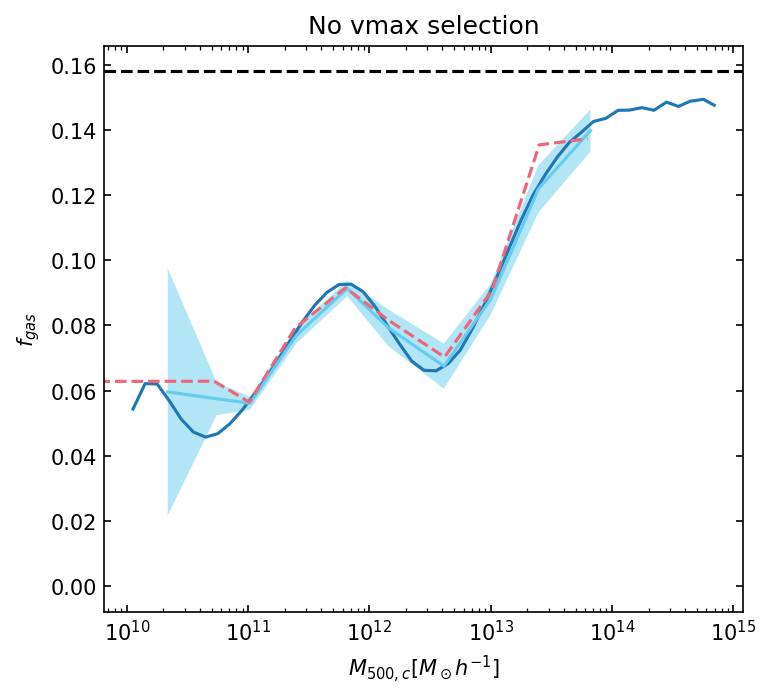

In [33]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.set_xscale('log')

ax.plot(fgas_total['m500'], fgas_total['f_gas'])
ax.plot(mean_m500, mean_fgas, color=colors[1])
# ax.plot(ens_m500[3], ens_fgas[3], color=colors[2], ls='--')
ax.plot(ens_m500[28], ens_fgas[28], color=colors[4], ls='--')

ax.fill_between(mean_m500, mean_fgas-err_fgas, mean_fgas+err_fgas, color=colors[1], alpha=0.5, edgecolor=None)
    
ax.axhline(0.158, color='k', ls='--')

ax.set_title('No vmax selection')

ax.set_ylabel('$f_{gas}$')
ax.set_xlabel('$M_{500,c}[M_\\odot h^{-1}]$')

In [34]:
sfr_mstar = hydro_split.halo_SFR(mhalo_edges=mass_edges, sel_mask=ens_sel, vmax_sel=False, draws=100, nbins=20)

2024-08-02 14:44:22,327 bacco.sims : Reading 90246895 items for SubhaloSFR
/lscratch/fgmaion/MTNG-resims/src/utils.py:325: RuntimeWarning: invalid value encountered in divide
  sSFR  = 1e10 * np.array(sSFR) / mstar
/lscratch/fgmaion/MTNG-resims/src/utils.py:325: RuntimeWarning: divide by zero encountered in divide
  sSFR  = 1e10 * np.array(sSFR) / mstar
/lscratch/fgmaion/MTNG-resims/src/utils.py:337: RuntimeWarning: invalid value encountered in divide
  sSFR_mean[d] /= weights[d]
/lscratch/fgmaion/MTNG-resims/src/utils.py:338: RuntimeWarning: invalid value encountered in divide
  mstar_mean[d] /= counts[d]


In [35]:
nbins=30

ens_sSFR = np.zeros((100, nbins-1))
ens_mstar = np.zeros((100, nbins-1))
weights = np.ones((100, nbins-1))


temp = hydro_split.halo_SFR(mhalo_edges=mass_edges, sel_mask=ens_sel, vmax_sel=False, draws=100, nbins=nbins)

for i in range(100):
    ens_sSFR[i] = temp['sSFR'][i]
    ens_mstar[i] = temp['mstar'][i]

    weights[i][np.where(np.isnan(ens_mstar[i]))] = 0

    ens_mstar[i][np.where(np.isnan(ens_mstar[i]))] = 0
    ens_mstar[i][np.where(np.isnan(ens_sSFR[i]))] = 0
    ens_sSFR[i][np.where(np.isnan(ens_sSFR[i]))] = 0
    ens_sSFR[i][np.where(np.isnan(ens_mstar[i]))] = 0
    

In [36]:
mean_sSFR   = np.sum(ens_sSFR, axis=0) / np.sum(weights, axis=0)
mean_mstar = np.sum(ens_mstar, axis=0) / np.sum(weights, axis=0)
err_sSFR    = np.sqrt( np.sum(ens_sSFR**2, axis=0) / np.sum(weights, axis=0) - ( np.sum(ens_sSFR, axis=0) / np.sum(weights, axis=0) )**2 )

/tmp/ipykernel_92207/45664116.py:1: RuntimeWarning: invalid value encountered in divide
  mean_sSFR   = np.sum(ens_sSFR, axis=0) / np.sum(weights, axis=0)
/tmp/ipykernel_92207/45664116.py:2: RuntimeWarning: invalid value encountered in divide
  mean_mstar = np.sum(ens_mstar, axis=0) / np.sum(weights, axis=0)
/tmp/ipykernel_92207/45664116.py:3: RuntimeWarning: invalid value encountered in divide
  err_sSFR    = np.sqrt( np.sum(ens_sSFR**2, axis=0) / np.sum(weights, axis=0) - ( np.sum(ens_sSFR, axis=0) / np.sum(weights, axis=0) )**2 )


In [37]:
sSFR_total = hydro_split.total_SFR(nbins=nbins)

/lscratch/fgmaion/MTNG-resims/src/utils.py:349: RuntimeWarning: divide by zero encountered in divide
  sSFR   = np.array(1e10 * self.sim.sub['SFR']) / mstar
/lscratch/fgmaion/MTNG-resims/src/utils.py:349: RuntimeWarning: invalid value encountered in divide
  sSFR   = np.array(1e10 * self.sim.sub['SFR']) / mstar


In [38]:
mstar_bauer = np.array([9, 9.5, 10, 10.5, 11])
ssfr_bauer = np.array([-0.7, -0.8,-0.81,-1,-1.3])
err_bauer_low = np.ones(5) * (10**(ssfr_bauer) - 10**(ssfr_bauer-0.5) )
err_bauer_high = np.ones(5) * (10**(ssfr_bauer+0.5) - 10**(ssfr_bauer) )

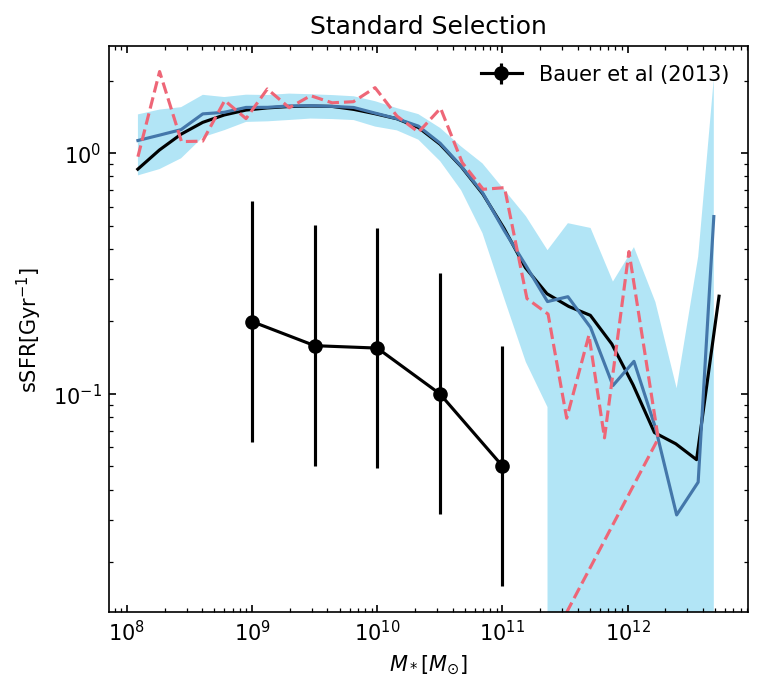

In [39]:
fig, ax = plt.subplots( dpi=150, figsize=(5.5,5), sharey=True)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel('sSFR[Gyr$^{-1}$]')
ax.set_xlabel('$M_*[M_{\\odot}]$')

ax.set_title('Standard Selection')

ax.plot(sSFR_total['mstar'][:-1], sSFR_total['sSFR'][:-1], color='k')
ax.plot(mean_mstar, mean_sSFR, color=colors[0])
ax.plot(ens_mstar[28][:-3], ens_sSFR[28][:-3], color=colors[4], ls='--')
# for i in range(20,25):
#     ax.plot(ens_mstar[i], ens_sSFR[i])

ax.fill_between(mean_mstar, mean_sSFR-err_sSFR, mean_sSFR+err_sSFR, color=colors[1], alpha=0.5, edgecolor=None)

ax.errorbar(10**(mstar_bauer), 10**(ssfr_bauer), [err_bauer_low, err_bauer_high],  marker='o', label='Bauer et al (2013)', color='k')

ax.legend()

### Cross-match the selected halos

In [40]:
# final_sel = np.zeros(mass_edges.shape[0], dtype=int)
# for i in range(mass_edges.shape[0]):
#     final_sel[i] = ens_sel['sel'][i][28][0]

In [58]:
with open("/lscratch/fgmaion/MTNG-resims/halo_selections/2160-A/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))

final_sel = np.array(final_sel)

In [25]:
from scipy.spatial import KDTree

In [59]:
X1 = mtng.fof['halo_pos'][final_sel]
X2 = mtng_dm.fof['halo_pos']

kdt = KDTree(X2, boxsize=500)
dist, ind = kdt.query(X1, k=100)

ind[np.where(dist==np.inf)] = -1

In [60]:
M1 = 1e10 * mtng.fof['halo_m200b'][final_sel]
M2 = 1e10 * mtng_dm.fof['halo_m200b'][ind]

pos1 = mtng.fof['halo_pos'][final_sel].T
pos2 = np.transpose(mtng_dm.fof['halo_pos'][ind], (2,0,1))

vmax_1 = mtng.sub['vmax'][mtng.fof['halo_firstsub'][final_sel]]
vmax_2 = mtng_dm.sub['vmax'][mtng_dm.fof['halo_firstsub'][ind]]

2024-08-05 10:34:09,190 bacco.sims : Reading 98233510 items for Group_M_Mean200


2024-08-05 10:34:10,416 bacco.sims : Reading 1780958 items for Group_M_Mean200
2024-08-05 10:34:10,803 bacco.sims : Reading 90246895 items for SubhaloVmax
2024-08-05 10:34:11,834 bacco.sims : Reading 98233510 items for halo_firstsub
2024-08-05 10:34:25,197 bacco.sims : Reading 2219376 items for SubhaloVmax
2024-08-05 10:34:25,287 bacco.sims : Reading 1780958 items for halo_firstsub


In [61]:
def metric(m1,m2,x1,x2,v1,v2,a,b,c):

    d_x = np.sqrt(np.sum((x1[...,np.newaxis]-x2)**2, axis=0))
    d_m = np.abs(np.log10(m1[...,np.newaxis]/m2))
    d_v = np.abs(v1[...,np.newaxis]-v2)

    return d_x**a + d_m**b + d_v**c


In [62]:
d = metric(M1,M2,pos1,pos2,vmax_1,vmax_2,2,0.3,0.3)

/tmp/ipykernel_123923/1876228836.py:4: RuntimeWarning: divide by zero encountered in divide
  d_m = np.abs(np.log10(m1[...,np.newaxis]/m2))


In [63]:
xmatch = np.zeros(len(M1), dtype=int)
dmatch = np.zeros(len(M1))

for i in range(len(M1)):
    xmatch[i] = ind[i,np.where(d[i]==d[i].min())[0][0]]
    dmatch[i] = dist[i,np.where(d[i]==d[i].min())[0][0]]

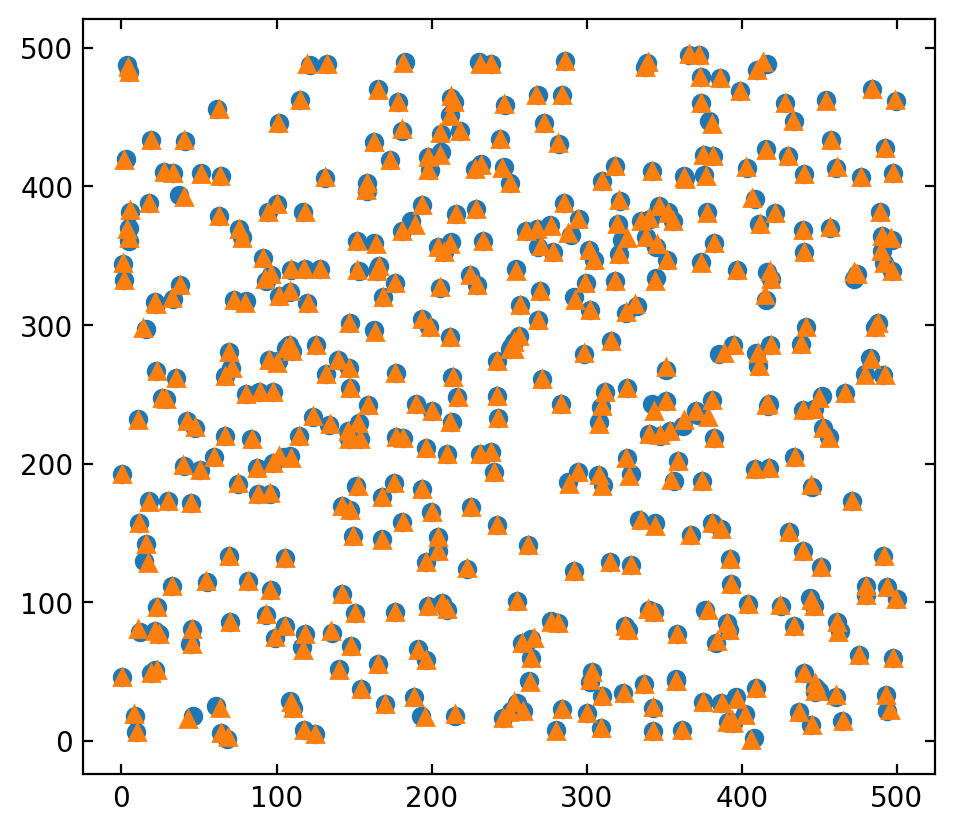

In [64]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.plot(mtng.fof['halo_pos'][final_sel][:,1], mtng.fof['halo_pos'][final_sel][:,2], marker='o', ls='')
ax.plot(mtng_dm.fof['halo_pos'][xmatch][:,1], mtng_dm.fof['halo_pos'][xmatch][:,2], marker='^', ls='')

Exception ignored in: <function Simulation.__del__ at 0x2b1bd26010d0>
Traceback (most recent call last):
  File "/lscratch/fgmaion/baccogit/bacco/simulation.py", line 580, in __del__
    self.cleanup()
  File "/lscratch/fgmaion/baccogit/bacco/simulation.py", line 10629, in cleanup
    clean_lazy(self, attributes)
  File "/lscratch/fgmaion/baccogit/bacco/utils.py", line 4112, in clean_lazy
    delattr(obj, t)
AttributeError: dm


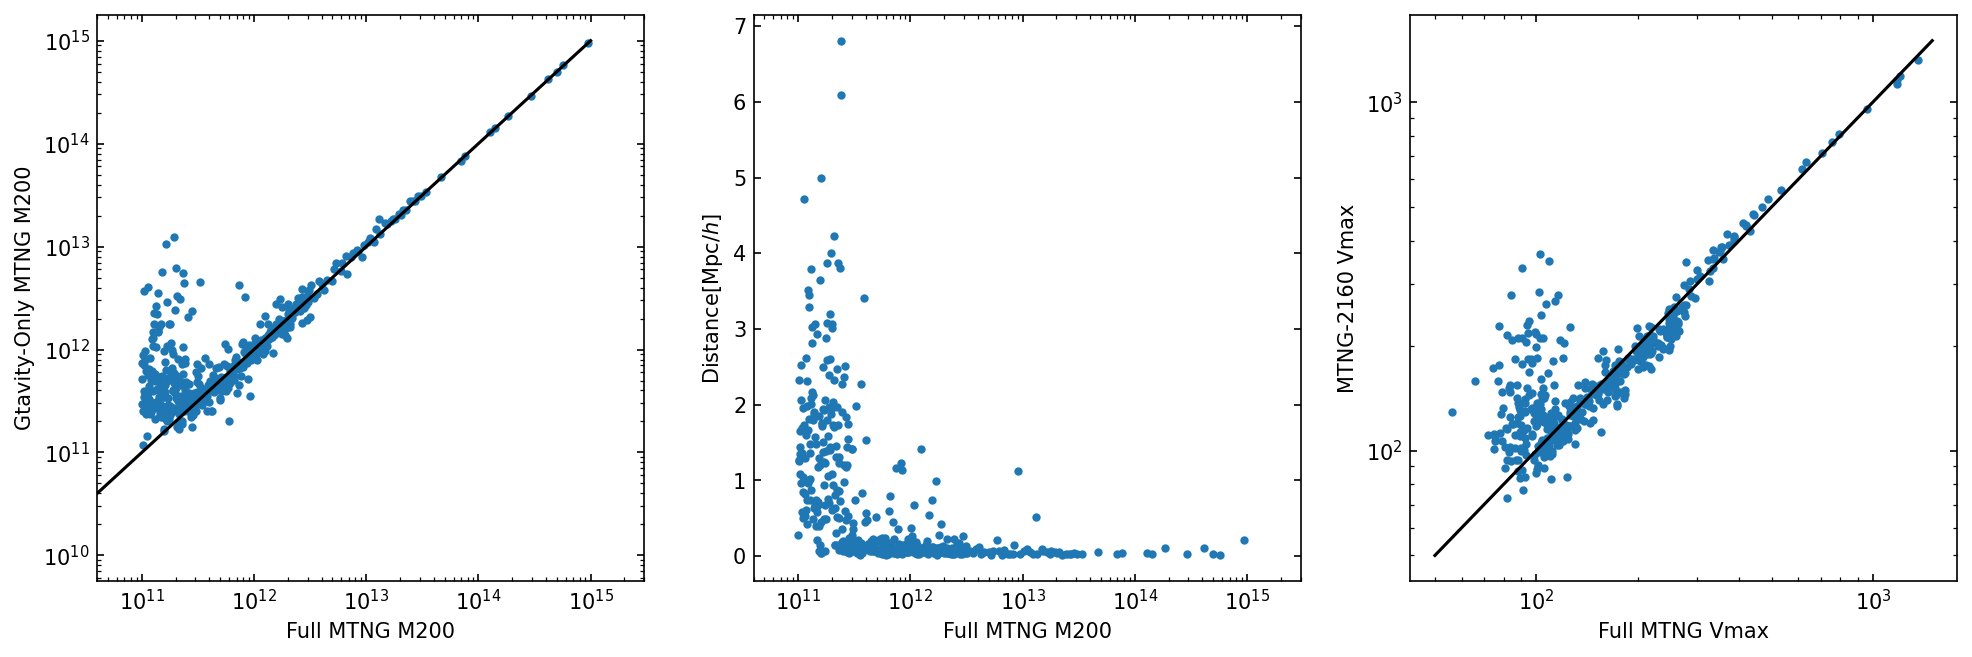

In [65]:
fig, ax = plt.subplots(1, 3, dpi=150, figsize=(16,5))

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ratio = np.zeros(xmatch.shape)
for i in range(xmatch.shape[0]):
    ratio[i] = mtng.fof['halo_m200b'][final_sel][i] / mtng_dm.fof['halo_m200b'][xmatch[i]]
    ax[0].plot(1e10*mtng.fof['halo_m200b'][final_sel][i], 1e10*mtng_dm.fof['halo_m200b'][xmatch[i]], marker='o', color='C0', ms=3)

ax[0].set_xlabel('Full MTNG M200')
ax[0].set_ylabel('Gtavity-Only MTNG M200')

ax[0].plot(np.logspace(10,15,10), np.logspace(10,15,10), color='k')

ax[0].set_xlim(4e10,3e15)

#

ax[1].set_xscale('log')

ax[1].set_xlabel('Full MTNG M200')
ax[1].set_ylabel('Distance$[$Mpc$/h]$')

for i in range(dmatch.shape[0]):
    ax[1].plot(1e10*mtng.fof['halo_m200b'][final_sel][i], dmatch[i], marker='o', color='C0', ms=3)

ax[1].set_xlim(4e10,3e15)

#

ax[2].set_xscale('log')
ax[2].set_yscale('log')

ax[2].set_xlabel('Full MTNG Vmax')
ax[2].set_ylabel('MTNG-2160 Vmax')

for i in range(dmatch.shape[0]):
    ax[2].plot(mtng.sub['vmax'][mtng.fof['halo_firstsub'][final_sel][i]], mtng_dm.sub['vmax'][mtng_dm.fof['halo_firstsub'][xmatch[i]]], marker='o', color='C0', ms=3)

ax[2].plot(np.linspace(50,1500,100), np.linspace(50,1500,100), color='k')

#ax[2].set_xlim(4e10,3e15)


In [32]:
halo_neigh = {}
grid_neigh = {}
i=0
while(ind[283,i]!=-1):
    halo_neigh[i] = mtng_dm.get_halo_particles(ihalo=ind[283,i], relative=False)
    grid_neigh[i] = bacco.statistics.compute_mesh(pos=halo_neigh[i] - np.mean(halo_neigh[0], axis=0) + 1.5, box=3, ngrid=128)
    i+=1

2024-08-05 10:20:55,977 bacco.sims : Reading 11273943 items for Group/GroupLen
2024-08-05 10:20:57,027 bacco.sims : Reading 11273943 items for GroupLen
2024-08-05 10:20:57,596 bacco.sims : Read data for 172227489/10077696000 particles...


/cosmos_storage/simulations/MTNG/DM-Gadget4/MTNG-L500-2160-A/snapdir_265/snapshot_265.0.hdf5


2024-08-05 10:21:14,708 bacco.sims : Read data for 172227489/10077696000 particles...
2024-08-05 10:21:14,721 bacco.sims : Read data for 168817832/10077696000 particles...
2024-08-05 10:21:30,997 bacco.sims : Read data for 168817832/10077696000 particles...
2024-08-05 10:21:31,002 bacco.sims : Read data for 167943350/10077696000 particles...


KeyboardInterrupt: 

In [267]:
mtng_dm.fof['halo_m200b'][xmatch[283]]

17.648134

In [268]:
mtng.fof['halo_m200b'][final_sel[283]]

82.8786

In [269]:
halo_pos = mtng.fof['halo_pos'] - np.mean(halo_neigh[0], axis=0) + 1.5

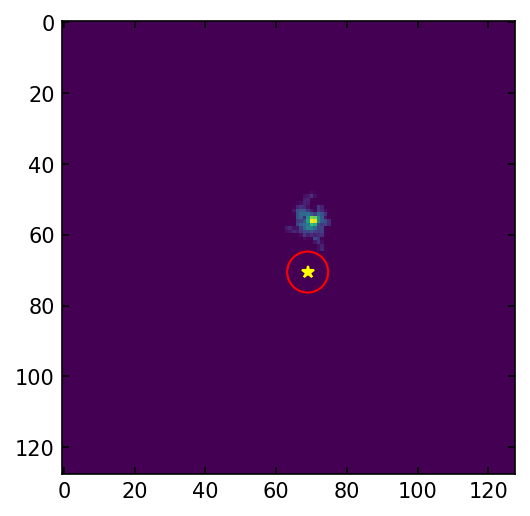

In [273]:
fig, ax = plt.subplots(dpi=150)

ax.imshow(np.log10(1+np.sum(grid_neigh[8][0,:,:,:],axis=0)))

ax.plot(halo_pos[final_sel[283],2]*128/3, halo_pos[final_sel[283],1]*128/3, marker='*', color='yellow')
circle1 = plt.Circle((halo_pos[final_sel[283],2]*128/3, halo_pos[final_sel[283],1]*128/3), mtng.fof['halo_r200b'][final_sel][283]*128/5, color='r', fill=False)

ax.add_patch(circle1)


In [994]:
mtng_dm.fof['halo_m200b'][xmatch[219]]

294.9152

In [996]:
mtng.fof['halo_m200b'][sel[1]]

8155.4595

In [66]:
with open("/lscratch/fgmaion/MTNG-resims/halo_selections/1080_dm_halo_sel_1pmbin.txt", 'w') as f:
    for i in range(len(xmatch)):
        if i==len(xmatch)-1:
            f.write(str(xmatch[i]))
        else:
            f.write(str(xmatch[i])+'\n')

# with open("/lscratch/fgmaion/MTNG-resims/halo_selections/hydro_halo_sel_1pmbin.txt", 'w') as f:
#     for i in range(len(final_sel)):
#         if i==len(final_sel)-1:
#             f.write(str(final_sel[i]))
#         else:
#             f.write(str(final_sel[i])+'\n')

In [67]:
#np.save("/cosmos_storage/data_sharing/resims_info/hydro_properties_halo_sel_1pmbin.npy", [{'pos':mtng.fof['halo_pos'][final_sel], 'm200b':mtng.fof['halo_m200b'][final_sel]}] )
np.save("/cosmos_storage/data_sharing/resims_info/1080_dm_properties_halo_sel_1pmbin.npy", [{'pos':mtng_dm.fof['halo_pos'][xmatch], 'm200b':mtng_dm.fof['halo_m200b'][xmatch]}] )

In [69]:
dm_pos = np.load("/cosmos_storage/data_sharing/resims_info/1080_dm_properties_halo_sel_1pmbin.npy", allow_pickle=True)[0]

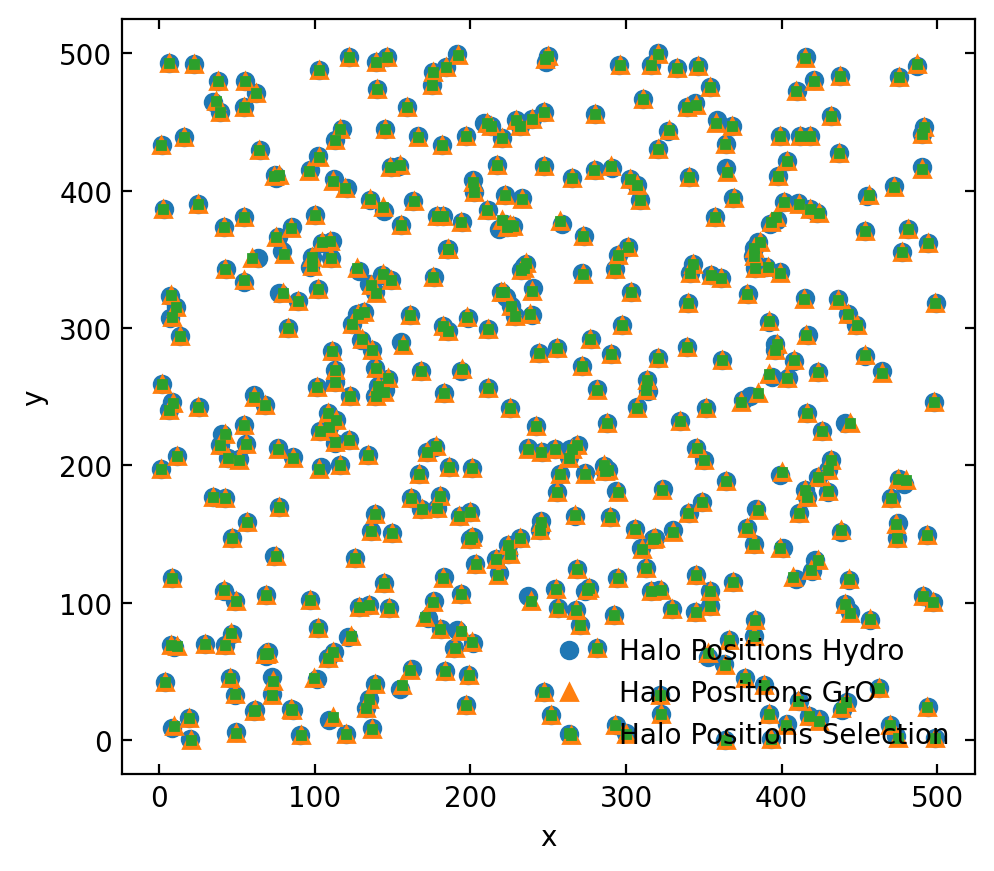

In [70]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.plot(mtng.fof['halo_pos'][final_sel][:,0], mtng.fof['halo_pos'][final_sel][:,1], marker='o', ls='', label='Halo Positions Hydro')
ax.plot(mtng_dm.fof['halo_pos'][xmatch][:,0], mtng_dm.fof['halo_pos'][xmatch][:,1], marker='^', ls='', label='Halo Positions GrO')
ax.plot(dm_pos['pos'][:,0], dm_pos['pos'][:,1], marker='s', ls='', ms=3, label='Halo Positions Selection')

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.legend()